# Naive Bayes — Breast Cancer Classification

**Goal:** Classify tumors as Malignant or Benign using a **probabilistic approach** based on Bayes' Theorem.

Naive Bayes computes the probability of each class given the observed features, and predicts the most probable class. It is called *naive* because it assumes all features are **independent** given the class — a simplification that works surprisingly well in practice.

**Dataset:** Wisconsin Breast Cancer dataset (569 samples, 30 features, binary target M/B).

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load Dataset

In [2]:
data = pd.read_csv("data.csv")

### Clean the Data

Drop `id` and the empty `Unnamed: 32` column.  
`M` = Malignant, `B` = Benign.

In [3]:
data.drop(["id", "Unnamed: 32"], axis=1,inplace=True)
data.head()
# malignant = M 
# benign = B

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
M = data[data.diagnosis == "M"] 
B = data[data.diagnosis == "B"] 

### Visualize the Classes

Scatter plot of `radius_mean` vs `texture_mean`. The partial separation between classes is visible — Naive Bayes will model the **probability distribution** of each feature within each class.

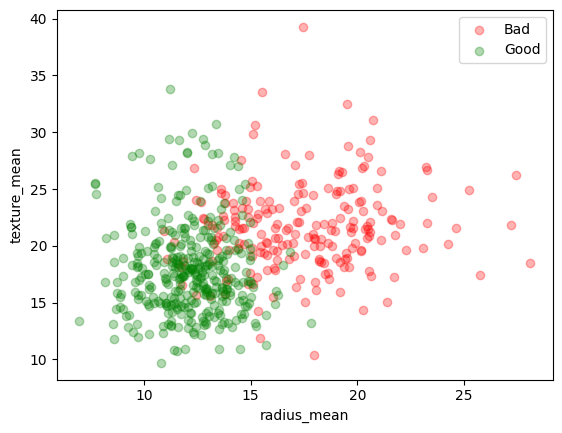

In [5]:
# scatter plot
plt.scatter(M.radius_mean, M.texture_mean,color="red", label="Bad",alpha=0.3)
plt.scatter(B.radius_mean, B.texture_mean,color="green", label="Good",alpha=0.3)
plt.xlabel("radius_mean")
plt.ylabel("texture_mean")
plt.legend()
plt.show()

### Encode Labels & Prepare Features

In [6]:
data.diagnosis = [1 if each == "M" else 0 for each in data.diagnosis]
x_data = data.drop(["diagnosis"], axis=1)
y = data.diagnosis.values

### Normalization

Scale features to `[0, 1]`. While Gaussian NB is less sensitive to scale than distance-based methods, normalization keeps results consistent across all algorithms in this project.

In [7]:
# Normalization
x = (x_data - np.min(x_data)) / np.max(x_data) - np.min(x_data)

### Train / Test Split

70% training, 30% testing.

In [8]:
# Train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=1)

### Train Gaussian Naive Bayes

`GaussianNB` assumes each feature follows a **Gaussian (normal) distribution** within each class.  
For each feature and class it learns:
- **μ** (mean) — center of the distribution
- **σ²** (variance) — spread of the distribution

During prediction, it uses these learned parameters to compute:
```
P(feature | class) = (1 / √(2πσ²)) · exp(−(x − μ)² / (2σ²))
```

**No hyperparameters to tune** — the model learns everything from the training data.

In [9]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(x_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


### Evaluate Accuracy

`nb.score(x_test, y_test)` reports the fraction of correctly classified test samples.

In [10]:
print("accuracy of SVM algorithm: ", nb.score(x_test,y_test))

accuracy of SVM algorithm:  0.9473684210526315
